# Exercise 2:
### Hierarchical Clustering (Agglomerative)

For this exercise, we will be using the `zoo.data` dataset which can be found on the UCI Machine Learning Repository, https://archive.ics.uci.edu/dataset/111/zoo

Your task is to prepare/clean the data in `zoo.data` and subsequently the cleaned dataset is to be used in the agglomerative clustering training process.

---

#### Load libraries
Load the necessary libraries for this exercise.

In [4]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

#### Data Preparation / Preprocessing
Perform the necessary preprocessing steps.

In [5]:
# Load the dataset
df = pd.read_csv('zoo.data', header=None)

In [6]:
columns = [
    "animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic",
    "predator", "toothed", "backbone", "breathes", "venomous", "fins", "legs",
    "tail", "domestic", "catsize", "type"
]
df.columns = columns

In [7]:
df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [8]:
df.shape

(101, 18)

In [9]:
zoo_features = df.drop(["animal_name", "type"], axis=1)

In [10]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(zoo_features)

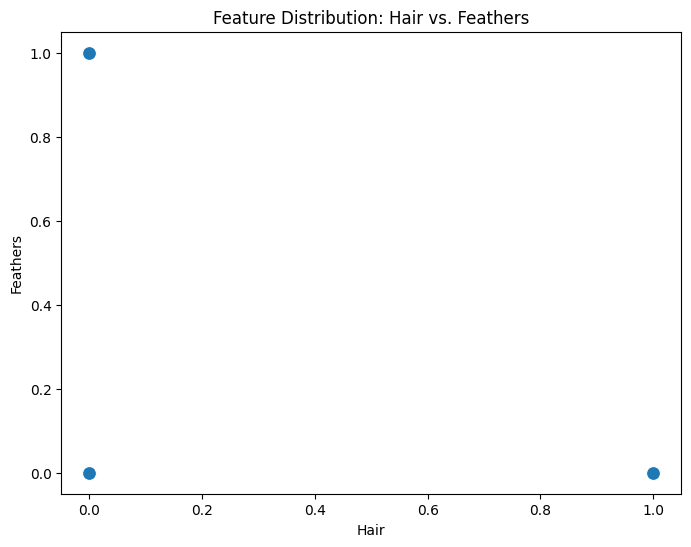

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=zoo_features["hair"],
    y=zoo_features["feathers"],
    s=100,
)
plt.title("Feature Distribution: Hair vs. Feathers")
plt.xlabel("Hair")
plt.ylabel("Feathers")
plt.show()

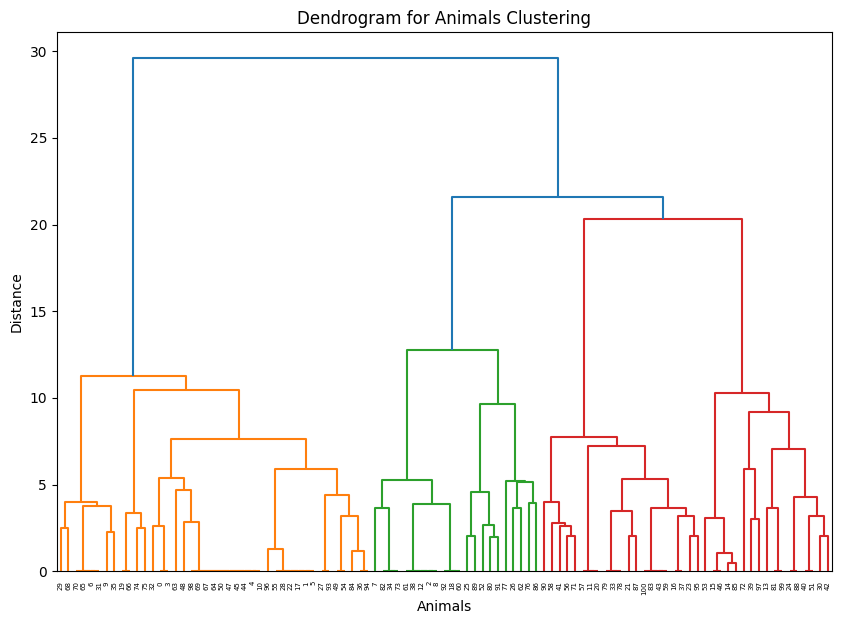

In [30]:
# Create a Dendrogram for Hierarchical Clustering
# Using Ward's method for linkage
linked = linkage(scaled_features, method="ward")

plt.figure(figsize=(10, 7))
plt.title("Dendrogram for Animals Clustering")
dendrogram(linked)
plt.xlabel("Animals")
plt.ylabel("Distance")
plt.show()

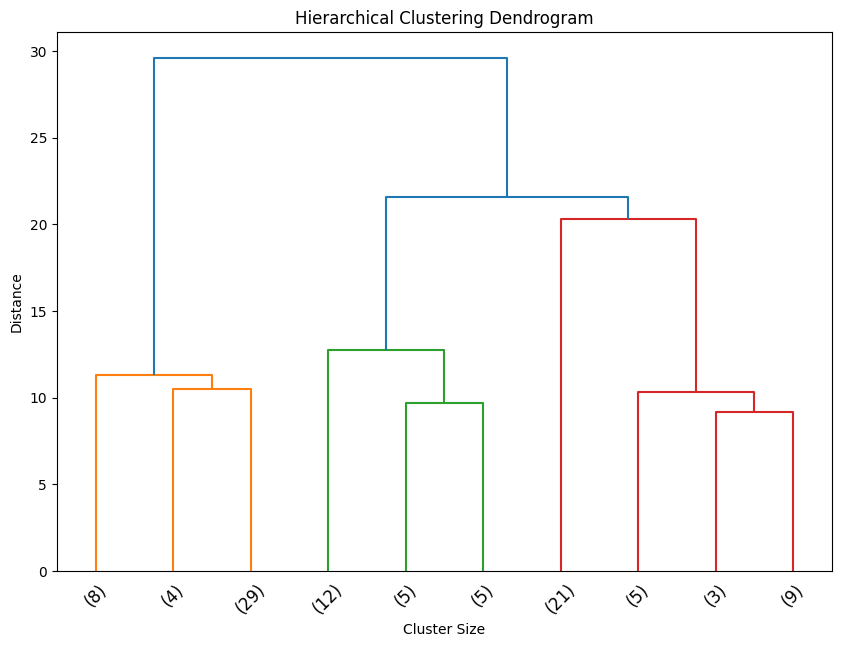

In [14]:
# Generate the linkage matrix for dendrogram
linkage_matrix = linkage(scaled_features, method="ward")

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, truncate_mode="lastp", p=10, leaf_rotation=45., leaf_font_size=12.)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

#### Model Training

In [18]:
num_clusters = 7
agglo_cluster = AgglomerativeClustering(
    n_clusters=num_clusters, metric="euclidean", linkage="ward"
)
clusters = agglo_cluster.fit_predict(scaled_features)

In [19]:
df["Cluster"] = agglo_cluster.fit_predict(scaled_features)

In [26]:
df

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,fins,legs,tail,domestic,catsize,type,Cluster,PCA1,PCA2,Cluster Label
0,aardvark,1,0,0,1,0,0,1,1,1,...,0,4,0,0,1,1,2,2.535256,-0.260278,Reptiles/Amphibians
1,antelope,1,0,0,1,0,0,0,1,1,...,0,4,1,0,1,1,2,2.877354,-0.401547,Reptiles/Amphibians
2,bass,0,0,1,0,0,1,1,1,1,...,1,0,1,0,0,4,4,-1.761003,3.705592,Insects
3,bear,1,0,0,1,0,0,1,1,1,...,0,4,0,0,1,1,2,2.535256,-0.260278,Reptiles/Amphibians
4,boar,1,0,0,1,0,0,1,1,1,...,0,4,1,0,1,1,2,2.818975,0.107081,Reptiles/Amphibians
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,...,0,2,1,0,1,1,2,2.764120,-0.065219,Reptiles/Amphibians
97,wasp,1,0,1,0,1,0,0,0,0,...,0,6,0,0,0,6,0,-1.667523,-3.219581,Mammals
98,wolf,1,0,0,1,0,0,1,1,1,...,0,4,1,0,1,1,2,2.818975,0.107081,Reptiles/Amphibians
99,worm,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,7,0,-2.018815,-1.257793,Mammals


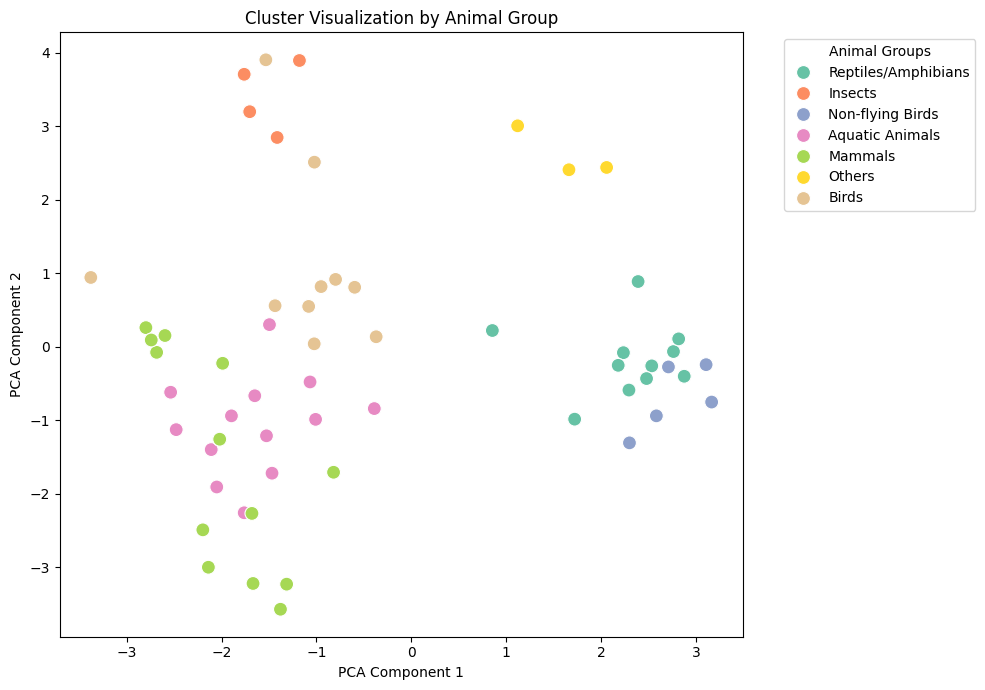

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

df["PCA1"] = pca_features[:, 0]
df["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster Label",
    palette="Set2",
    data=df,
    s=100
)

plt.title("Cluster Visualization by Animal Group")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Animal Groups", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
